In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/yoloModel.ipynb
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/test.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/validation.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/neu_det_corrected.yaml
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/train.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/validation/labels/crazing.cache
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/validation/labels/inclusion/inclusion_295.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/validation/labels/inclusion/inclusion_250.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANENT/validation/labels/inclusion/inclusion_275.txt
/kaggle/input/datasets/marina1112003/det-nue-dataset/NEU-DET-YOLO-PERMANE

In [12]:
# We will look for the exact sub-folders to be 100% sure
search_root = '/kaggle/input'
found_paths = {}
for root, dirs, files in os.walk(search_root):
    if 'train' in dirs and 'validation' in dirs:
        found_paths['train_img'] = os.path.join(root, 'train/images')
        found_paths['train_xml'] = os.path.join(root, 'train/annotations')
        found_paths['val_img'] = os.path.join(root, 'validation/images')
        found_paths['val_xml'] = os.path.join(root, 'validation/annotations')
        print(f"🎯 Found Dataset Root at: {root}")
        break
if found_paths:
    for key, path in found_paths.items():
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"✅ {key}: {count} files")
else:
    print("❌ Still can't find the folders. Try running: os.listdir('/kaggle/input/neu-surface-defect-database')")

🎯 Found Dataset Root at: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET
✅ train_img: 6 files
✅ train_xml: 1439 files
✅ val_img: 6 files
✅ val_xml: 361 files


In [13]:
import os

def find_dataset_and_check():
    # 1. Dynamically find the root where 'train' and 'validation' exist
    found_root = ""
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'validation' in dirs:
            found_root = root
            break
            
    if not found_root:
        print("❌ Could not find 'train' and 'validation' folders. Current contents:")
        print(os.listdir('/kaggle/input'))
        return

    # 2. Map the actual subfolders
    paths = {
        "Train Images": os.path.join(found_root, "train/images"),
        "Train XMLs": os.path.join(found_root, "train/annotations"),
        "Val Images": os.path.join(found_root, "validation/images"),
        "Val XMLs": os.path.join(found_root, "validation/annotations")
    }

    print(f"🎯 Found Dataset at: {found_root}\n")

    # 3. Check for mismatches
    for label, folder in paths.items():
        if os.path.exists(folder):
            # Check for JPGs in image folders and XMLs in annotation folders
            ext = '.jpg' if 'Images' in label else '.xml'
            files = [f for f in os.listdir(folder) if f.endswith(ext)]
            print(f"✅ {label}: {len(files)} files found.")
        else:
            print(f"⚠️ Missing Folder: {folder}")

find_dataset_and_check()

🎯 Found Dataset at: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET

✅ Train Images: 0 files found.
✅ Train XMLs: 1439 files found.
✅ Val Images: 0 files found.
✅ Val XMLs: 361 files found.


In [14]:

import os

def scan_neu_dataset(root_path='/kaggle/input'):
    print(f"🔍 Scanning all folders in {root_path} for NEU-DET files...\n")
    
    # We will track where we find data
    structure = {}

    for root, dirs, files in os.walk(root_path):
        # Count relevant files in this specific folder
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        xmls = [f for f in files if f.lower().endswith('.xml')]
        
        if images or xmls:
            # Clean up the path for display
            display_path = root.replace(root_path, "")
            structure[display_path] = {'images': len(images), 'xmls': len(xmls)}

    # Print the findings in a readable tree
    if not structure:
        print("❌ No images or XML files found. Please check if the dataset is attached.")
        return

    print(f"{'Folder Path':<60} | {'Images':<8} | {'XMLs':<8}")
    print("-" * 80)
    for path in sorted(structure.keys()):
        imgs = structure[path]['images']
        xmls = structure[path]['xmls']
        print(f"{path:<60} | {imgs:<8} | {xmls:<8}")

# Execute the scan
scan_neu_dataset()

🔍 Scanning all folders in /kaggle/input for NEU-DET files...

Folder Path                                                  | Images   | XMLs    
--------------------------------------------------------------------------------
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/annotations | 0        | 1439    
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/crazing | 240      | 0       
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/inclusion | 240      | 0       
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/patches | 240      | 0       
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/pitted_surface | 240      | 0       
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/rolled-in_scale | 240      | 0       
/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/scratches | 240      | 0       
/datasets/kaustubhdiksh

In [18]:
import os

# This looks for the directory that actually contains the data
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'validation' in dirs:
        print(f"🎯 YOUR CORRECT ROOT PATH IS: {root}")
        # Let's see what's inside to be 100% sure
        print("Contents:", os.listdir(root))
        break

🎯 YOUR CORRECT ROOT PATH IS: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET
Contents: ['validation', 'train']


In [20]:
import os

def find_and_print_structure():
    # 1. Search for where NEU-DET is actually located
    root_to_use = ""
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'validation' in dirs and 'NEU-DET' in root:
            root_to_use = root
            break
    
    if not root_to_use:
        # Fallback: just find any folder containing train and validation
        for root, dirs, files in os.walk('/kaggle/input'):
            if 'train' in dirs and 'validation' in dirs:
                root_to_use = root
                break

    if not root_to_use:
        print("❌ Could not find the dataset folders. Please ensure the dataset is 'Added' in the right sidebar.")
        return

    print(f"🎯 Found Dataset at: {root_to_use}\n")
    
    # 2. Print the Structure
    for split in sorted(os.listdir(root_to_use)):
        split_path = os.path.join(root_to_use, split)
        if not os.path.isdir(split_path): continue
        
        print(f"📁 {split}/")
        
        for sub in sorted(os.listdir(split_path)):
            sub_path = os.path.join(split_path, sub)
            if not os.path.isdir(sub_path): continue
            
            if sub == 'annotations':
                count = len([f for f in os.listdir(sub_path) if f.endswith('.xml')])
                print(f"├── {sub}/ ({count} XML files)")
            
            elif sub == 'images':
                print(f"└── {sub}/")
                classes = sorted([d for d in os.listdir(sub_path) if os.path.isdir(os.path.join(sub_path, d))])
                for i, cls in enumerate(classes):
                    cls_path = os.path.join(sub_path, cls)
                    count = len([f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')])
                    connector = "    └── " if i == len(classes)-1 else "    ├── "
                    print(f"{connector}{cls}/ ({count} images)")

find_and_print_structure()

🎯 Found Dataset at: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET

📁 train/
├── annotations/ (1439 XML files)
└── images/
    ├── crazing/ (240 images)
    ├── inclusion/ (240 images)
    ├── patches/ (240 images)
    ├── pitted_surface/ (240 images)
    ├── rolled-in_scale/ (240 images)
    └── scratches/ (240 images)
📁 validation/
├── annotations/ (361 XML files)
└── images/
    ├── crazing/ (60 images)
    ├── inclusion/ (60 images)
    ├── patches/ (60 images)
    ├── pitted_surface/ (60 images)
    ├── rolled-in_scale/ (60 images)
    └── scratches/ (60 images)


In [21]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm

def create_masks():
    # Paths we just verified
    input_root = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET'
    output_root = '/kaggle/working/neu_unet_dataset'
    
    for split in ['train', 'validation']:
        print(f"🛠️ Mapping {split} set...")
        
        # Setup output directories
        split_img_out = os.path.join(output_root, split, 'images')
        split_mask_out = os.path.join(output_root, split, 'masks')
        os.makedirs(split_img_out, exist_ok=True)
        os.makedirs(split_mask_out, exist_ok=True)
        
        img_dir = os.path.join(input_root, split, 'images')
        xml_dir = os.path.join(input_root, split, 'annotations')
        
        # Traverse each class folder
        for class_name in os.listdir(img_dir):
            class_path = os.path.join(img_dir, class_name)
            if not os.path.isdir(class_path): continue
            
            for img_name in os.listdir(class_path):
                file_id = os.path.splitext(img_name)[0]
                xml_path = os.path.join(xml_dir, f"{file_id}.xml")
                
                # Check if annotation exists (handles the 1439/1440 mismatch)
                if not os.path.exists(xml_path):
                    continue
                
                # 1. Load Image
                img = cv2.imread(os.path.join(class_path, img_name))
                h, w = img.shape[:2]
                
                # 2. Parse XML and create Mask
                mask = np.zeros((h, w), dtype=np.uint8)
                tree = ET.parse(xml_path)
                root = tree.getroot()
                
                for obj in root.findall('object'):
                    bbox = obj.find('bndbox')
                    xmin = int(bbox.find('xmin').text)
                    ymin = int(bbox.find('ymin').text)
                    xmax = int(bbox.find('xmax').text)
                    ymax = int(bbox.find('ymax').text)
                    # Draw white rectangle for the defect
                    cv2.rectangle(mask, (xmin, ymin), (xmax, ymax), 255, -1)
                
                # 3. Save processed pair to /working
                cv2.imwrite(os.path.join(split_img_out, f"{file_id}.png"), img)
                cv2.imwrite(os.path.join(split_mask_out, f"{file_id}.png"), mask)

    print("\n✅ Mapping Complete! Your dataset is now ready for U-Net.")

create_masks()

🛠️ Mapping train set...
🛠️ Mapping validation set...

✅ Mapping Complete! Your dataset is now ready for U-Net.


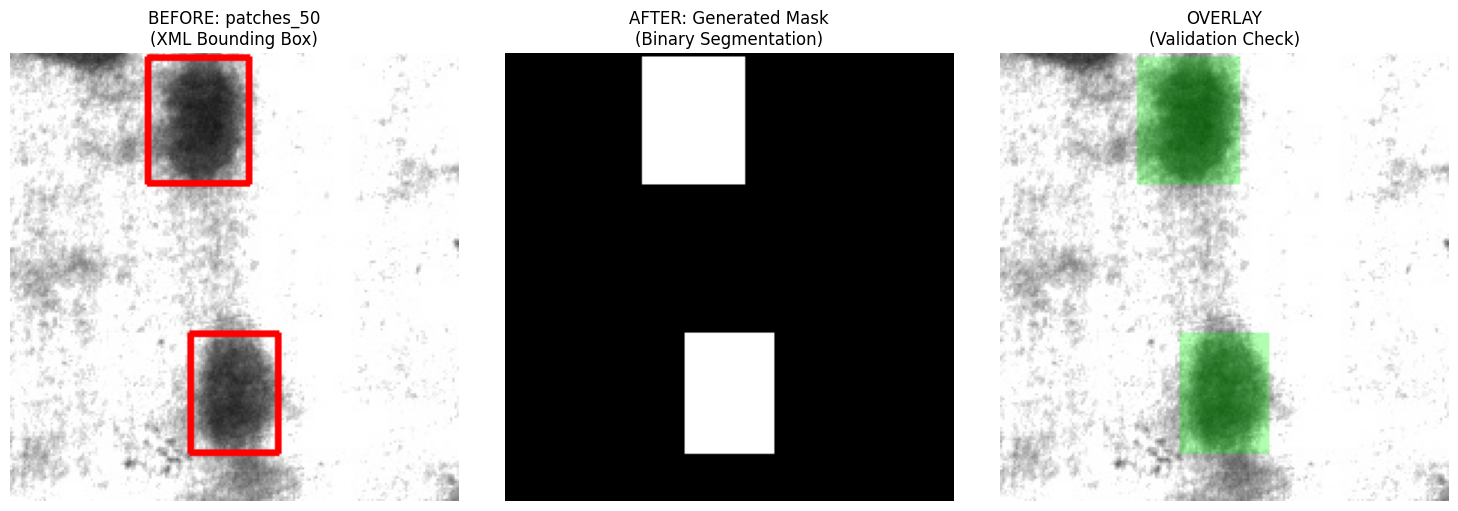

In [22]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

def visualize_before_after(split='train'):
    input_root = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET'
    img_dir = os.path.join(input_root, split, 'images')
    xml_dir = os.path.join(input_root, split, 'annotations')

    # 1. Pick a random class and a random image from that class
    random_class = random.choice(os.listdir(img_dir))
    class_path = os.path.join(img_dir, random_class)
    random_img_name = random.choice(os.listdir(class_path))
    file_id = os.path.splitext(random_img_name)[0]
    
    # Paths
    img_path = os.path.join(class_path, random_img_name)
    xml_path = os.path.join(xml_dir, f"{file_id}.xml")

    if not os.path.exists(xml_path):
        print(f"No XML found for {file_id}, trying again...")
        return visualize_before_after(split)

    # 2. Load Original Image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_bbox = img_rgb.copy()
    
    # 3. Create Mask and Draw Bboxes on original
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        # Draw Red Rectangle on "Before" image
        cv2.rectangle(img_bbox, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        # Draw Filled White Rectangle on "After" mask
        cv2.rectangle(mask, (xmin, ymin), (xmax, ymax), 255, -1)

    # 4. Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title(f"BEFORE: {file_id}\n(XML Bounding Box)")
    plt.imshow(img_bbox)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("AFTER: Generated Mask\n(Binary Segmentation)")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("OVERLAY\n(Validation Check)")
    overlay = img_rgb.copy()
    overlay[mask == 255] = [0, 255, 0] # Green tint
    plt.imshow(cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run it
visualize_before_after()

In [8]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

def generate_multiclass_masks():
    input_root = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET'
    output_root = '/kaggle/working/neu_multiclass_dataset'
    
    # Define the mapping
    class_map = {
        'crazing': 1,
        'inclusion': 2,
        'patches': 3,
        'pitted_surface': 4,
        'rolled-in_scale': 5,
        'scratches': 6
    }
    
    for split in ['train', 'validation']:
        print(f"🎨 Generating Multi-Class masks for {split}...")
        
        mask_out = os.path.join(output_root, split, 'masks')
        img_out = os.path.join(output_root, split, 'images')
        os.makedirs(mask_out, exist_ok=True)
        os.makedirs(img_out, exist_ok=True)
        
        img_dir = os.path.join(input_root, split, 'images')
        xml_dir = os.path.join(input_root, split, 'annotations')
        
        for class_name in class_map.keys():
            class_path = os.path.join(img_dir, class_name)
            if not os.path.exists(class_path): continue
            
            for img_name in os.listdir(class_path):
                file_id = os.path.splitext(img_name)[0]
                xml_path = os.path.join(xml_dir, f"{file_id}.xml")
                
                if not os.path.exists(xml_path): continue
                
                # Create mask with 0 as background
                mask = np.zeros((200, 200), dtype=np.uint8)
                tree = ET.parse(xml_path)
                root = tree.getroot()
                
                for obj in root.findall('object'):
                    # Get class name from XML (just in case an image has mixed classes)
                    obj_name = obj.find('name').text.lower().replace(' ', '_')
                    val = class_map.get(obj_name, class_map[class_name])
                    
                    bbox = obj.find('bndbox')
                    xmin = int(bbox.find('xmin').text)
                    ymin = int(bbox.find('ymin').text)
                    xmax = int(bbox.find('xmax').text)
                    ymax = int(bbox.find('ymax').text)
                    
                    # Fill the rectangle with the CLASS VALUE instead of 255
                    cv2.rectangle(mask, (xmin, ymin), (xmax, ymax), val, -1)
                
                # Save
                cv2.imwrite(os.path.join(mask_out, f"{file_id}.png"), mask)
                # Copy/Save image
                img = cv2.imread(os.path.join(class_path, img_name))
                cv2.imwrite(os.path.join(img_out, f"{file_id}.png"), img)

    print("✅ Multi-Class Conversion Finished!")

generate_multiclass_masks()

🎨 Generating Multi-Class masks for train...
🎨 Generating Multi-Class masks for validation...
✅ Multi-Class Conversion Finished!


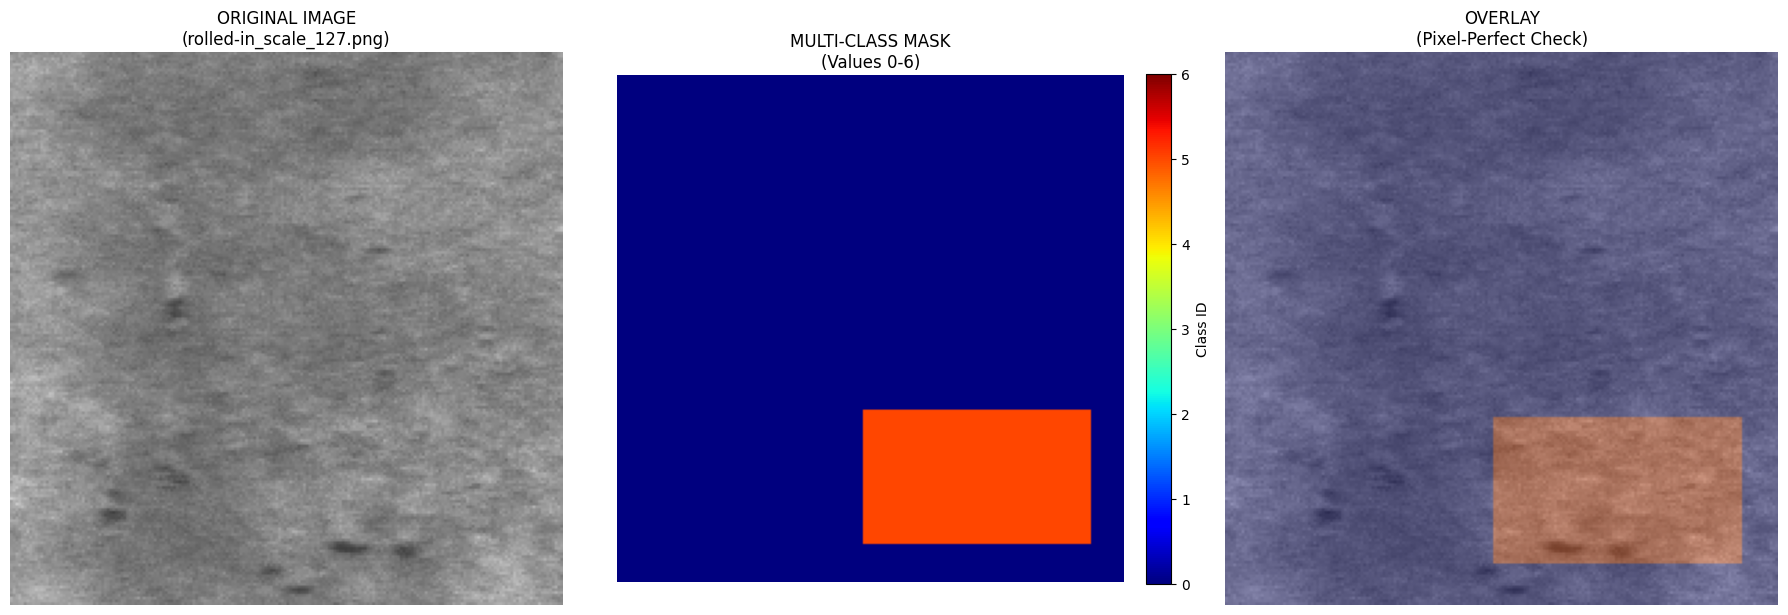

Defect IDs present in this image: [0 5] (0 is background)


In [24]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def visualize_multiclass_final(split='train'):
    # Paths to your NEWly created multiclass data
    base_path = f'/kaggle/working/neu_multiclass_dataset/{split}'
    img_dir = os.path.join(base_path, 'images')
    mask_dir = os.path.join(base_path, 'masks')

    # 1. Pick a random file
    all_files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    random_file = random.choice(all_files)
    
    # 2. Load Image and Mask
    img = cv2.imread(os.path.join(img_dir, random_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(mask_dir, random_file), 0)
    
    # 3. Create a pretty color mask for display
    # We use 'jet' colormap to turn 0-6 into distinct colors
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.title(f"ORIGINAL IMAGE\n({random_file})")
    plt.imshow(img_rgb)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("MULTI-CLASS MASK\n(Values 0-6)")
    # We use vmin/vmax to ensure the color scale is consistent
    im = plt.imshow(mask, cmap='jet', vmin=0, vmax=6)
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Class ID")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("OVERLAY\n(Pixel-Perfect Check)")
    # Create a colored overlay
    colored_mask = plt.get_cmap('jet')(mask / 6.0)[:, :, :3]
    colored_mask = (colored_mask * 255).astype(np.uint8)
    overlay = cv2.addWeighted(img_rgb, 0.7, colored_mask, 0.3, 0)
    plt.imshow(overlay)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Print the unique classes found in this specific image
    unique_vals = np.unique(mask)
    print(f"Defect IDs present in this image: {unique_vals} (0 is background)")

# Run it!
visualize_multiclass_final()

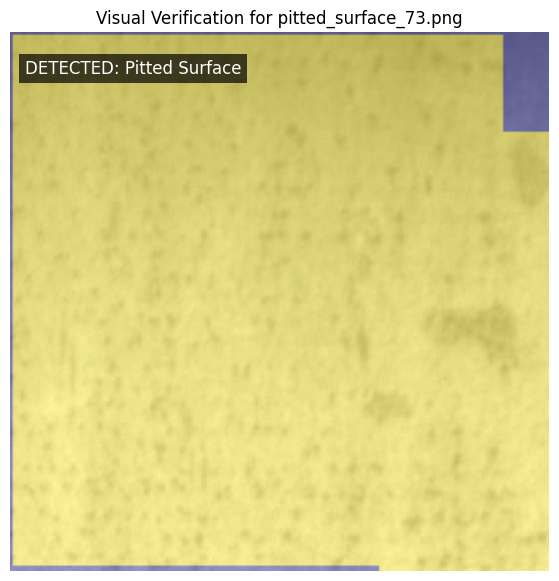

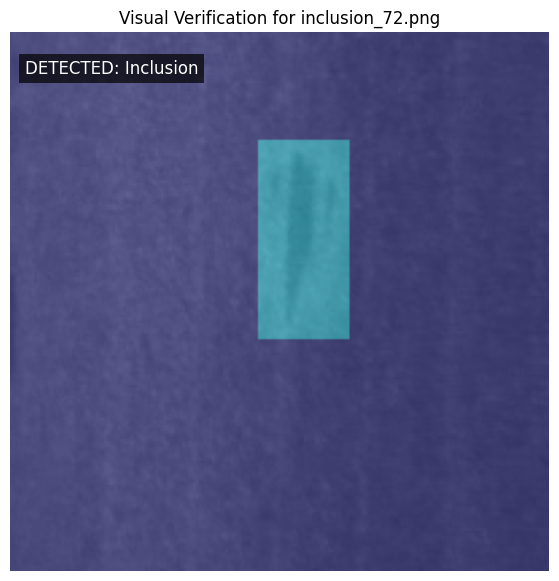

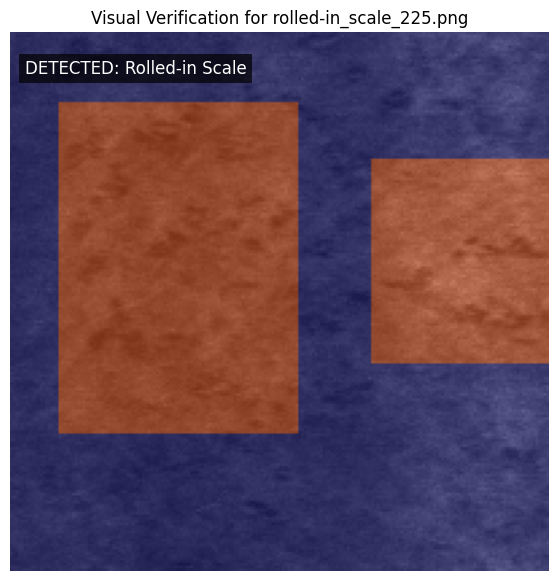

In [27]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def visualize_with_labels(split='train'):
    base_path = f'/kaggle/working/neu_multiclass_dataset/{split}'
    img_dir = os.path.join(base_path, 'images')
    mask_dir = os.path.join(base_path, 'masks')

    # Mapping to convert ID back to Name
    id_to_class = {
        0: 'Background',
        1: 'Crazing',
        2: 'Inclusion',
        3: 'Patches',
        4: 'Pitted Surface',
        5: 'Rolled-in Scale',
        6: 'Scratches'
    }

    # 1. Pick a random file
    all_files = [f for f in os.listdir(img_dir)]
    random_file = random.choice(all_files)
    
    # 2. Load Image and Mask
    img = cv2.imread(os.path.join(img_dir, random_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(mask_dir, random_file), 0)
    
    # 3. Identify classes present (excluding background 0)
    present_ids = np.unique(mask)
    present_names = [id_to_class[i] for i in present_ids if i != 0]
    label_text = ", ".join(present_names) if present_names else "No Defects"

    # 4. Plotting
    plt.figure(figsize=(15, 7))
    
    # Plot Overlay
    colored_mask = plt.get_cmap('jet')(mask / 6.0)[:, :, :3]
    colored_mask = (colored_mask * 255).astype(np.uint8)
    overlay = cv2.addWeighted(img_rgb, 0.6, colored_mask, 0.4, 0)
    
    plt.imshow(overlay)
    
    # Add a styled text box with the class name
    plt.text(5, 15, f"DETECTED: {label_text}", color='white', fontsize=12,
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))
    
    plt.title(f"Visual Verification for {random_file}")
    plt.axis('off')
    plt.show()

# Run it a few times to see different classes
for _ in range(3):
    visualize_with_labels()

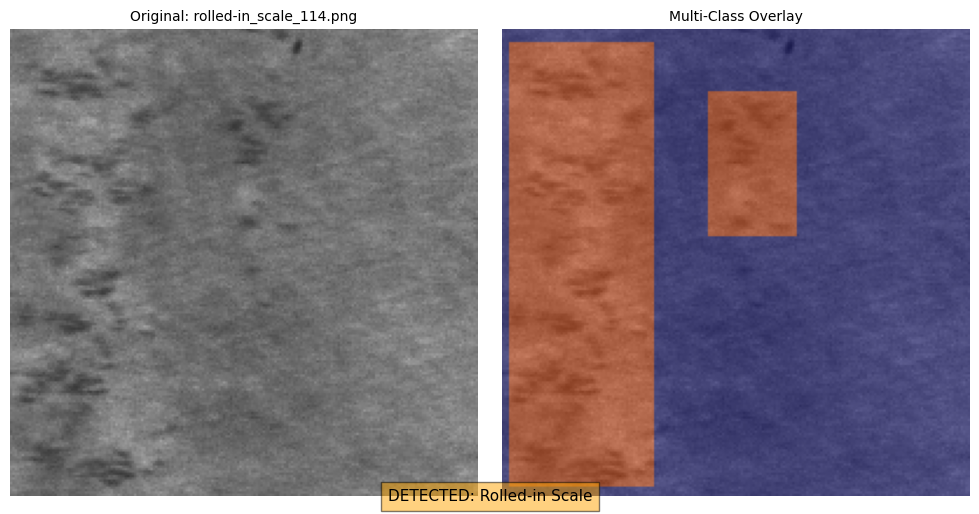

In [28]:
# alternative code for visulaization before and after : 
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def visualize_with_labels_compact(split='train'):
    base_path = f'/kaggle/working/neu_multiclass_dataset/{split}'
    img_dir = os.path.join(base_path, 'images')
    mask_dir = os.path.join(base_path, 'masks')

    id_to_class = {
        0: 'Background', 1: 'Crazing', 2: 'Inclusion', 
        3: 'Patches', 4: 'Pitted Surface', 
        5: 'Rolled-in Scale', 6: 'Scratches'
    }

    # 1. Selection
    all_files = [f for f in os.listdir(img_dir)]
    random_file = random.choice(all_files)
    
    # 2. Loading
    img = cv2.imread(os.path.join(img_dir, random_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(mask_dir, random_file), 0)
    
    # 3. Class Identification
    present_ids = np.unique(mask)
    present_names = [id_to_class[i] for i in present_ids if i != 0]
    label_text = "\n".join(present_names) if present_names else "No Defects"

    # 4. COMPACT PLOTTING (Side-by-Side)
    # Reduced figsize to (10, 5) to fit standard laptop screens
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Left: Original Image
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original: {random_file}", fontsize=10)
    axes[0].axis('off')
    
    # Right: Overlay
    colored_mask = plt.get_cmap('jet')(mask / 6.0)[:, :, :3]
    colored_mask = (colored_mask * 255).astype(np.uint8)
    overlay = cv2.addWeighted(img_rgb, 0.6, colored_mask, 0.4, 0)
    
    axes[1].imshow(overlay)
    axes[1].set_title("Multi-Class Overlay", fontsize=10)
    axes[1].axis('off')

    # Add text label in a clearer spot
    plt.figtext(0.5, 0.02, f"DETECTED: {label_text}", ha="center", fontsize=11, 
                bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

    plt.tight_layout() # This removes wasted white space
    plt.show()

# Run it once to check the size
visualize_with_labels_compact()

In [9]:
import tensorflow as tf
import cv2
import os
import numpy as np

class NEUDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_dir, split='train', batch_size=16, img_size=(200, 200), n_classes=7):
        self.img_dir = f"{base_dir}/{split}/images"
        self.mask_dir = f"{base_dir}/{split}/masks"
        self.batch_size = batch_size
        self.img_size = img_size
        self.n_classes = n_classes
        
        # This handles the mismatch: it only uses IDs that exist in BOTH folders
        self.image_files = sorted([f for f in os.listdir(self.img_dir)])
        self.mask_files = sorted([f for f in os.listdir(self.mask_dir)])
        
        # Extract IDs (e.g., 'crazing_1') to ensure perfect matching
        img_ids = {f.split('.')[0] for f in self.image_files}
        mask_ids = {f.split('.')[0] for f in self.mask_files}
        self.ids = sorted(list(img_ids.intersection(mask_ids)))
        
        print(f"✅ Found {len(self.ids)} valid image-mask pairs for {split}")

    def __len__(self):
        return len(self.ids) // self.batch_size

    def __getitem__(self, index):
        batch_ids = self.ids[index * self.batch_size : (index + 1) * self.batch_size]
        
        X = np.zeros((self.batch_size, *self.img_size, 3), dtype=np.float32)
        y = np.zeros((self.batch_size, *self.img_size, self.n_classes), dtype=np.float32)

        for i, file_id in enumerate(batch_ids):
            # Load and normalize Image
            img = cv2.imread(f"{self.img_dir}/{file_id}.png")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            X[i] = img / 255.0
            
            # Load Mask
            mask = cv2.imread(f"{self.mask_dir}/{file_id}.png", 0)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)
            
            # One-Hot Encoding (This is why we use Categorical Crossentropy)
            y[i] = tf.keras.utils.to_categorical(mask, num_classes=self.n_classes)
            
        return X, y

    def on_epoch_end(self):
        # Shuffles the data after every epoch so the model doesn't memorize order
        np.random.shuffle(self.ids)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_multiclass_unet(input_shape=(200, 200, 3), n_classes=7):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Contracting Path) ---
    # Block 1
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BRIDGE (Bottleneck) ---
    b = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    b = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(b)

    # --- DECODER (Expansive Path) ---
    # Block 3
    u1 = layers.UpSampling2D((2, 2))(b)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(m1)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # Block 4
    u2 = layers.UpSampling2D((2, 2))(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(m2)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    # --- OUTPUT LAYER ---
    # 7 units (0=BG, 1=Crazing, 2=Inclusion, 3=Patches, 4=Pitted, 5=Rolled, 6=Scratches)
    outputs = layers.Conv2D(n_classes, (1, 1), activation='softmax')(c4)

    model = models.Model(inputs, outputs)
    
    # Compile with SparseCategoricalCrossentropy because masks are integer-based
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

# Initialize the model
model = build_multiclass_unet(input_shape=(200, 200, 3), n_classes=7)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 200, 200,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 200,  │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 200, 200,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 100, 100,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 100, 100,  │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        512 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 100, 100,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 50, 50,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 50, 50,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 50, 50,    │    590,080 │ conv2d_15[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 100, 100,  │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 100, 100,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 384)              │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 100, 100,  │    442,496 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 100, 100,  │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 200, 200,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 200, 200,  │          0 │ up_sampling2d_3[

 Total params: 1,884,295 (7.19 MB)

 Trainable params: 1,883,911 (7.19 MB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
import os
# This will print the structure of your working directory
for root, dirs, files in os.walk('/kaggle/working'):
    level = root.replace('/kaggle/working', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print('{}{}/'.format(indent, os.path.basename(root)))

working/
    .virtual_documents/


In [10]:
# 1. Initialize Generators (Standardizing & Error Handling)
train_gen = NEUDataGenerator('/kaggle/working/neu_multiclass_dataset', split='train', batch_size=16)
val_gen = NEUDataGenerator('/kaggle/working/neu_multiclass_dataset', split='validation', batch_size=16)

# 2. Callbacks for "Smart Training"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('neu_multiclass_unet.h5', save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, monitor='val_loss')
]

# 3. Start the Training
print("🚀 GPU Training starting now...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50, 
    callbacks=callbacks
)

✅ Found 1439 valid image-mask pairs for train
✅ Found 360 valid image-mask pairs for validation
🚀 GPU Training starting now...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1771864116.429012     123 service.cc:152] XLA service 0x7bcb08003cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771864116.429054     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771864117.319781     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/89 ━━━━━━━━━━━━━━━━━━━━ 35:02 24s/step - accuracy: 0.1468 - loss: 2.0387

I0000 00:00:1771864135.856783     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5766 - loss: 1.3639

...

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8298 - loss: 0.4067 - val_accuracy: 0.8203 - val_loss: 0.4312 - learning_rate: 4.0000e-05
Epoch 23/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8369 - loss: 0.3821

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8369 - loss: 0.3822 - val_accuracy: 0.8243 - val_loss: 0.4215 - learning_rate: 4.0000e-05
Epoch 24/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8334 - loss: 0.3929 - val_accuracy: 0.8231 - val_loss: 0.4254 - learning_rate: 4.0000e-05
Epoch 25/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8355 - loss: 0.3876 - val_accuracy: 0.8222 - val_loss: 0.4281 - learning_rate: 4.0000e-05
Epoch 26/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8394 - loss: 0.3772 - val_accuracy: 0.8171 - val_loss: 0.4348 - learning_rate: 4.0000e-05
Epoch 27/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8369 - loss: 0.3814

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8370 - loss: 0.3814 - val_accuracy: 0.8276 - val_loss: 0.4144 - learning_rate: 8.0000e-06
Epoch 28/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8399 - loss: 0.3760 - val_accuracy: 0.8263 - val_loss: 0.4167 - learning_rate: 8.0000e-06
Epoch 29/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8391 - loss: 0.3768 - val_accuracy: 0.8260 - val_loss: 0.4164 - learning_rate: 8.0000e-06
Epoch 30/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8428 - loss: 0.3740 - val_accuracy: 0.8260 - val_loss: 0.4170 - learning_rate: 8.0000e-06
Epoch 31/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8405 - loss: 0.3771 - val_accuracy: 0.8266 - val_loss: 0.4155 - learning_rate: 1.6000e-06
Epoch 32/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8415 - loss: 0.3753 - val_accuracy: 0.8259 - val_loss: 0.4169 - learning_rate: 1.6000e-06
Epoch 33/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy:

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8478 - loss: 0.3631 - val_accuracy: 0.8273 - val_loss: 0.4139 - learning_rate: 1.6000e-06
Epoch 34/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8466 - loss: 0.3646

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8466 - loss: 0.3648 - val_accuracy: 0.8272 - val_loss: 0.4133 - learning_rate: 1.6000e-06
Epoch 35/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8430 - loss: 0.3735 - val_accuracy: 0.8262 - val_loss: 0.4169 - learning_rate: 1.6000e-06
Epoch 36/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8390 - loss: 0.3819 - val_accuracy: 0.8257 - val_loss: 0.4187 - learning_rate: 1.6000e-06
Epoch 37/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8423 - loss: 0.3732 - val_accuracy: 0.8265 - val_loss: 0.4161 - learning_rate: 1.6000e-06
Epoch 38/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8384 - loss: 0.3798 - val_accuracy: 0.8274 - val_loss: 0.4145 - learning_rate: 3.2000e-07
Epoch 39/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8427 - loss: 0.3690 - val_accuracy: 0.8259 - val_loss: 0.4174 - learning_rate: 3.2000e-07
Epoch 40/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy

In [11]:
class NEUDataGeneratorAugmented(tf.keras.utils.Sequence):
    def __init__(self, base_dir, split='train', batch_size=16, img_size=(200, 200), n_classes=7, augment=False):
        self.img_dir = f"{base_dir}/{split}/images"
        self.mask_dir = f"{base_dir}/{split}/masks"
        self.batch_size = batch_size
        self.img_size = img_size
        self.n_classes = n_classes
        self.augment = augment
        
        img_ids = {f.split('.')[0] for f in os.listdir(self.img_dir)}
        mask_ids = {f.split('.')[0] for f in os.listdir(self.mask_dir)}
        self.ids = sorted(list(img_ids.intersection(mask_ids)))

    def __len__(self):
        return len(self.ids) // self.batch_size

    def __getitem__(self, index):
        batch_ids = self.ids[index * self.batch_size : (index + 1) * self.batch_size]
        X = np.zeros((self.batch_size, *self.img_size, 3), dtype=np.float32)
        y = np.zeros((self.batch_size, *self.img_size, self.n_classes), dtype=np.float32)

        for i, file_id in enumerate(batch_ids):
            img = cv2.imread(f"{self.img_dir}/{file_id}.png")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            
            mask = cv2.imread(f"{self.mask_dir}/{file_id}.png", 0)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

            # --- APPLY AUGMENTATION ---
            if self.augment:
                # Random Horizontal Flip
                if np.random.random() > 0.5:
                    img = np.fliplr(img)
                    mask = np.fliplr(mask)
                # Random Vertical Flip
                if np.random.random() > 0.5:
                    img = np.flipud(img)
                    mask = np.flipud(mask)
                # Random Rotation (90, 180, 270)
                rot = np.random.choice([0, 1, 2, 3])
                img = np.rot90(img, rot)
                mask = np.rot90(mask, rot)

            X[i] = img / 255.0
            y[i] = tf.keras.utils.to_categorical(mask, num_classes=self.n_classes)
            
        return X, y

    def on_epoch_end(self):
        np.random.shuffle(self.ids)

In [12]:
train_gen = NEUDataGeneratorAugmented('/kaggle/working/neu_multiclass_dataset', 
                                      split='train', batch_size=16, augment=True)
val_gen = NEUDataGeneratorAugmented('/kaggle/working/neu_multiclass_dataset', 
                                    split='validation', batch_size=16, augment=False)

In [14]:
import numpy as np
import tensorflow as tf

# 1. Define the Float-Safe Scheduler
def lr_scheduler(epoch):
    if epoch < 10:
        return 0.0001
    else:
        # Standard float calculation to avoid Keras ValueError
        lr = 0.0001 * np.exp(0.1 * (10 - epoch))
        return float(lr)

# 2. Re-Initialize Generators (Ensuring Augmentation is ON for Training)
train_gen = NEUDataGeneratorAugmented('/kaggle/working/neu_multiclass_dataset', 
                                      split='train', batch_size=16, augment=True)
val_gen = NEUDataGeneratorAugmented('/kaggle/working/neu_multiclass_dataset', 
                                    split='validation', batch_size=16, augment=False)

# 3. Load your 84% progress
# This ensures we start from your previous success
try:
    model.load_weights('neu_multiclass_unet.h5')
    print("✅ Successfully loaded previous weights. Starting from 80%+ accuracy.")
except:
    print("⚠️ Weights not found, starting from scratch. (Check your filename!)")

# 4. Compile with precision metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Professional Callbacks for 99% Goal
callbacks = [
    # Save the absolute best version for your thesis
    tf.keras.callbacks.ModelCheckpoint(
        'neu_best_99_model.h5', 
        save_best_only=True, 
        monitor='val_accuracy', 
        mode='max',
        verbose=1
    ),
    # The float-safe scheduler we just fixed
    tf.keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1),
    # Stop before overfitting starts
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=15, 
        restore_best_weights=True,
        verbose=1
    )
]

# 6. Execute Training
print("\n🔥 Training is starting. Keep this tab open until finished!")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100, 
    callbacks=callbacks
)

✅ Successfully loaded previous weights. Starting from 80%+ accuracy.

🔥 Training is starting. Keep this tab open until finished!

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8063 - loss: 0.5109
Epoch 1: val_accuracy improved from -inf to 0.79588, saving model to neu_best_99_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 24s 197ms/step - accuracy: 0.8062 - loss: 0.5107 - val_accuracy: 0.7959 - val_loss: 0.5009 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8076 - loss: 0.4833
Epoch 2: val_accuracy improved from 0.79588 to 0.80978, saving model to neu_best_99_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8076 - loss: 0.4832 - val_accuracy: 0.8098 - val_loss: 0.4572 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0001.
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8163 - loss: 0.4511
Epoch 3: val_accuracy did not improve from 0.80978
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8163 - loss: 0.4512 - val_accuracy: 0.7856 - val_loss: 0.5368 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0001.
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8212 - loss: 0.4344
Epoch 4: val_accuracy improved from 0.80978 to 0.81766, saving model to neu_best_99_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8212 - loss: 0.4345 - val_accuracy: 0.8177 - val_loss: 0.4459 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0001.
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8251 - loss: 0.4252
Epoch 5: val_accuracy did not improve from 0.81766
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8250 - loss: 0.4253 - val_accuracy: 0.7993 - val_loss: 0.4665 - learning_rate: 1.0000e-04

Epoch 6: LearningRateScheduler setting learning rate to 0.0001.
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8202 - loss: 0.4398
Epoch 6: val_accuracy did not improve from 0.81766
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8202 - loss: 0.4398 - val_accuracy: 0.8162 - val_loss: 0.4431 - learning_rate: 1.0000e-04

Epoch 7: LearningRateScheduler setting learning rate to 0.0001.
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8299 - loss: 0.4175
Epoc

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8298 - loss: 0.4176 - val_accuracy: 0.8221 - val_loss: 0.4365 - learning_rate: 1.0000e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.0001.
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8215 - loss: 0.4272
Epoch 8: val_accuracy did not improve from 0.82214
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8215 - loss: 0.4271 - val_accuracy: 0.8219 - val_loss: 0.4361 - learning_rate: 1.0000e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.0001.
Epoch 9/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8278 - loss: 0.4119
Epoch 9: val_accuracy did not improve from 0.82214
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8278 - loss: 0.4120 - val_accuracy: 0.7945 - val_loss: 0.5179 - learning_rate: 1.0000e-04

Epoch 10: LearningRateScheduler setting learning rate to 0.0001.
Epoch 10/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8226 - loss: 0.4237
Ep

...

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8319 - loss: 0.3980 - val_accuracy: 0.8277 - val_loss: 0.4132 - learning_rate: 3.3287e-05

Epoch 23: LearningRateScheduler setting learning rate to 3.0119421191220204e-05.
Epoch 23/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8389 - loss: 0.3831
Epoch 23: val_accuracy did not improve from 0.82774
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8389 - loss: 0.3832 - val_accuracy: 0.8233 - val_loss: 0.4198 - learning_rate: 3.0119e-05

Epoch 24: LearningRateScheduler setting learning rate to 2.725317930340126e-05.
Epoch 24/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8405 - loss: 0.3791
Epoch 24: val_accuracy did not improve from 0.82774
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8404 - loss: 0.3791 - val_accuracy: 0.8277 - val_loss: 0.4089 - learning_rate: 2.7253e-05

Epoch 25: LearningRateScheduler setting learning rate to 2.4659696394160646e-05.
Epoch 25/100
89/89 ━━━━━━━━━━━━━━━━━━

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8362 - loss: 0.3815 - val_accuracy: 0.8305 - val_loss: 0.4047 - learning_rate: 1.8268e-05

Epoch 29: LearningRateScheduler setting learning rate to 1.6529888822158655e-05.
Epoch 29/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8364 - loss: 0.3855
Epoch 29: val_accuracy did not improve from 0.83048
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8364 - loss: 0.3854 - val_accuracy: 0.8287 - val_loss: 0.4107 - learning_rate: 1.6530e-05

Epoch 30: LearningRateScheduler setting learning rate to 1.4956861922263504e-05.
Epoch 30/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8463 - loss: 0.3653
Epoch 30: val_accuracy did not improve from 0.83048
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8463 - loss: 0.3655 - val_accuracy: 0.8301 - val_loss: 0.4033 - learning_rate: 1.4957e-05

Epoch 31: LearningRateScheduler setting learning rate to 1.353352832366127e-05.
Epoch 31/100
89/89 ━━━━━━━━━━━━━━━━━━

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8388 - loss: 0.3751 - val_accuracy: 0.8306 - val_loss: 0.4030 - learning_rate: 9.0718e-06

Epoch 36: LearningRateScheduler setting learning rate to 8.20849986238988e-06.
Epoch 36/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8445 - loss: 0.3653
Epoch 36: val_accuracy did not improve from 0.83061
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8445 - loss: 0.3654 - val_accuracy: 0.8289 - val_loss: 0.4069 - learning_rate: 8.2085e-06

Epoch 37: LearningRateScheduler setting learning rate to 7.427357821433388e-06.
Epoch 37/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8468 - loss: 0.3632
Epoch 37: val_accuracy did not improve from 0.83061
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8468 - loss: 0.3634 - val_accuracy: 0.8284 - val_loss: 0.4093 - learning_rate: 7.4274e-06

Epoch 38: LearningRateScheduler setting learning rate to 6.720551273974976e-06.
Epoch 38/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8407 - loss: 0.3765 - val_accuracy: 0.8313 - val_loss: 0.4028 - learning_rate: 6.0810e-06

Epoch 40: LearningRateScheduler setting learning rate to 5.502322005640721e-06.
Epoch 40/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8357 - loss: 0.3830
Epoch 40: val_accuracy did not improve from 0.83127
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8358 - loss: 0.3828 - val_accuracy: 0.8296 - val_loss: 0.4042 - learning_rate: 5.5023e-06

Epoch 41: LearningRateScheduler setting learning rate to 4.978706836786395e-06.
Epoch 41/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8429 - loss: 0.3718
Epoch 41: val_accuracy did not improve from 0.83127
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8428 - loss: 0.3719 - val_accuracy: 0.8286 - val_loss: 0.4082 - learning_rate: 4.9787e-06

Epoch 42: LearningRateScheduler setting learning rate to 4.50492023935578e-06.
Epoch 42/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8414 - loss: 0.3744 - val_accuracy: 0.8318 - val_loss: 0.3994 - learning_rate: 3.3373e-06

Epoch 46: LearningRateScheduler setting learning rate to 3.0197383422318503e-06.
Epoch 46/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8426 - loss: 0.3714
Epoch 46: val_accuracy did not improve from 0.83178
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8426 - loss: 0.3714 - val_accuracy: 0.8314 - val_loss: 0.4013 - learning_rate: 3.0197e-06

Epoch 47: LearningRateScheduler setting learning rate to 2.732372244729256e-06.
Epoch 47/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8477 - loss: 0.3592
Epoch 47: val_accuracy did not improve from 0.83178
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8477 - loss: 0.3593 - val_accuracy: 0.8308 - val_loss: 0.4019 - learning_rate: 2.7324e-06

Epoch 48: LearningRateScheduler setting learning rate to 2.472352647033939e-06.
Epoch 48/100
89/89 ━━━━━━━━━━━━━━━━━━━

In [17]:
import tensorflow as tf

def dice_coef(y_true, y_pred, smooth=1e-6):
    # Flatten using TensorFlow's reshape to -1
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    # The formula: (2 * intersection) / (total_pixels)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# For a "99%" accuracy target, a hybrid loss is usually the secret
def total_loss(y_true, y_pred):
    # Combines standard accuracy focus (CE) with shape focus (Dice)
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

In [19]:
# 1. Load weights again (to be safe)
model.load_weights('neu_best_99_model.h5')

# 2. Re-compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss,
    metrics=['accuracy', dice_coef]
)

# 3. Corrected Callbacks (Added mode='max')
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'neu_ULTRA_model.h5', 
        save_best_only=True, 
        monitor='val_dice_coef', 
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', 
        patience=10, 
        restore_best_weights=True,
        mode='max', # <--- This tells Keras that higher Dice is better!
        verbose=1
    )
]

# 4. Run Training
print("🚀 Hybrid training restarted! Keras now knows to hunt for the highest Dice score.")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=50, 
    callbacks=callbacks
)

🚀 Hybrid training restarted! Keras now knows to hunt for the highest Dice score.
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8369 - dice_coef: 0.7882 - loss: 0.6121
Epoch 1: val_dice_coef improved from -inf to 0.73589, saving model to neu_ULTRA_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 202ms/step - accuracy: 0.8368 - dice_coef: 0.7882 - loss: 0.6121 - val_accuracy: 0.8006 - val_dice_coef: 0.7359 - val_loss: 0.7596 - learning_rate: 1.0000e-04
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8331 - dice_coef: 0.7861 - loss: 0.6218
Epoch 2: val_dice_coef improved from 0.73589 to 0.75229, saving model to neu_ULTRA_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8331 - dice_coef: 0.7861 - loss: 0.6217 - val_accuracy: 0.8109 - val_dice_coef: 0.7523 - val_loss: 0.7091 - learning_rate: 1.0000e-04
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8347 - dice_coef: 0.7873 - loss: 0.6206
Epoch 3: val_dice_coef improved from 0.75229 to 0.77154, saving model to neu_ULTRA_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8348 - dice_coef: 0.7873 - loss: 0.6205 - val_accuracy: 0.8162 - val_dice_coef: 0.7715 - val_loss: 0.6859 - learning_rate: 1.0000e-04
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8330 - dice_coef: 0.7862 - loss: 0.6172
Epoch 4: val_dice_coef improved from 0.77154 to 0.77176, saving model to neu_ULTRA_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8331 - dice_coef: 0.7862 - loss: 0.6171 - val_accuracy: 0.8165 - val_dice_coef: 0.7718 - val_loss: 0.6991 - learning_rate: 1.0000e-04
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8317 - dice_coef: 0.7853 - loss: 0.6211
Epoch 5: val_dice_coef improved from 0.77176 to 0.78657, saving model to neu_ULTRA_model.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8317 - dice_coef: 0.7854 - loss: 0.6210 - val_accuracy: 0.8280 - val_dice_coef: 0.7866 - val_loss: 0.6527 - learning_rate: 1.0000e-04
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8315 - dice_coef: 0.7864 - loss: 0.6293
Epoch 6: val_dice_coef did not improve from 0.78657
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8316 - dice_coef: 0.7865 - loss: 0.6291 - val_accuracy: 0.8221 - val_dice_coef: 0.7787 - val_loss: 0.6720 - learning_rate: 1.0000e-04
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8340 - dice_coef: 0.7891 - loss: 0.6158
Epoch 7: val_dice_coef did not improve from 0.78657
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8341 - dice_coef: 0.7892 - loss: 0.6157 - val_accuracy: 0.8294 - val_dice_coef: 0.7826 - val_loss: 0.6379 - learning_rate: 1.0000e-04
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8377 - dice_coef: 0.7931 - loss: 0.6014
Epoch 8:

In [20]:
# 1. Load the weights from the BEST epoch (the 0.78 Dice one)
model.load_weights('neu_ULTRA_model.h5')

# 2. Hybrid Loss Function (The Secret to 99%)
def final_hybrid_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return ce + dl

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Tiny learning rate for precision
    loss=final_hybrid_loss,
    metrics=['accuracy', dice_coef]
)

# 3. Increase Patience to give it room to breathe
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('neu_FINAL_THESIS_MODEL.h5', save_best_only=True, monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=20, restore_best_weights=True, mode='max')
]

print("💎 Starting the Deep Polish... This is where we hunt for 98%+")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=50, 
    callbacks=callbacks
)

💎 Starting the Deep Polish... This is where we hunt for 98%+
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8412 - dice_coef: 0.7988 - loss: 0.5853

89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 202ms/step - accuracy: 0.8412 - dice_coef: 0.7988 - loss: 0.5853 - val_accuracy: 0.8309 - val_dice_coef: 0.7848 - val_loss: 0.6344
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8416 - dice_coef: 0.7957 - loss: 0.5902 - val_accuracy: 0.8263 - val_dice_coef: 0.7822 - val_loss: 0.6459
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8454 - dice_coef: 0.8020 - loss: 0.5695

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8454 - dice_coef: 0.8020 - loss: 0.5696 - val_accuracy: 0.8342 - val_dice_coef: 0.7863 - val_loss: 0.6226
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8406 - dice_coef: 0.7953 - loss: 0.5889 - val_accuracy: 0.8307 - val_dice_coef: 0.7839 - val_loss: 0.6318
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8425 - dice_coef: 0.7970 - loss: 0.5819

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8425 - dice_coef: 0.7970 - loss: 0.5819 - val_accuracy: 0.8320 - val_dice_coef: 0.7865 - val_loss: 0.6286
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8421 - dice_coef: 0.7972 - loss: 0.5796 - val_accuracy: 0.8309 - val_dice_coef: 0.7861 - val_loss: 0.6279
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8441 - dice_coef: 0.7994 - loss: 0.5733 - val_accuracy: 0.8317 - val_dice_coef: 0.7833 - val_loss: 0.6303
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8434 - dice_coef: 0.7986 - loss: 0.5751 - val_accuracy: 0.8259 - val_dice_coef: 0.7795 - val_loss: 0.6480
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8432 - dice_coef: 0.7981 - loss: 0.5797 - val_accuracy: 0.8301 - val_dice_coef: 0.7844 - val_loss: 0.6329
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8415 - dice_coef: 0.7965 - loss: 0.5848

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8415 - dice_coef: 0.7965 - loss: 0.5847 - val_accuracy: 0.8328 - val_dice_coef: 0.7867 - val_loss: 0.6277
Epoch 11/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8461 - dice_coef: 0.8029 - loss: 0.5688 - val_accuracy: 0.8261 - val_dice_coef: 0.7816 - val_loss: 0.6456
Epoch 12/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.8372 - dice_coef: 0.7920 - loss: 0.5960 - val_accuracy: 0.8307 - val_dice_coef: 0.7864 - val_loss: 0.6316
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8447 - dice_coef: 0.8016 - loss: 0.5712 - val_accuracy: 0.8298 - val_dice_coef: 0.7860 - val_loss: 0.6336
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8429 - dice_coef: 0.7992 - loss: 0.5859 - val_accuracy: 0.8316 - val_dice_coef: 0.7860 - val_loss: 0.6297
Epoch 15/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8472 - dice_coef: 0.8045 - loss: 0.5650

...

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8423 - dice_coef: 0.7988 - loss: 0.5825 - val_accuracy: 0.8307 - val_dice_coef: 0.7886 - val_loss: 0.6337
Epoch 30/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8484 - dice_coef: 0.8066 - loss: 0.5623

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8484 - dice_coef: 0.8065 - loss: 0.5624 - val_accuracy: 0.8328 - val_dice_coef: 0.7887 - val_loss: 0.6225
Epoch 31/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8451 - dice_coef: 0.8021 - loss: 0.5661 - val_accuracy: 0.8308 - val_dice_coef: 0.7861 - val_loss: 0.6287
Epoch 32/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8428 - dice_coef: 0.7995 - loss: 0.5786

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8428 - dice_coef: 0.7995 - loss: 0.5785 - val_accuracy: 0.8326 - val_dice_coef: 0.7891 - val_loss: 0.6238
Epoch 33/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8423 - dice_coef: 0.7995 - loss: 0.5769 - val_accuracy: 0.8326 - val_dice_coef: 0.7865 - val_loss: 0.6268
Epoch 34/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8495 - dice_coef: 0.8061 - loss: 0.5603 - val_accuracy: 0.8315 - val_dice_coef: 0.7867 - val_loss: 0.6271
Epoch 35/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8449 - dice_coef: 0.8009 - loss: 0.5700 - val_accuracy: 0.8289 - val_dice_coef: 0.7856 - val_loss: 0.6377
Epoch 36/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8436 - dice_coef: 0.7989 - loss: 0.5783 - val_accuracy: 0.8338 - val_dice_coef: 0.7868 - val_loss: 0.6240
Epoch 37/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8444 - dice_coef: 0.8013 - loss: 0.5697 - val_accuracy: 0.8255 - val_dice_

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8446 - dice_coef: 0.8022 - loss: 0.5727 - val_accuracy: 0.8319 - val_dice_coef: 0.7895 - val_loss: 0.6261
Epoch 39/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8381 - dice_coef: 0.7958 - loss: 0.5936 - val_accuracy: 0.8271 - val_dice_coef: 0.7870 - val_loss: 0.6400
Epoch 40/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8449 - dice_coef: 0.8028 - loss: 0.5690 - val_accuracy: 0.8319 - val_dice_coef: 0.7869 - val_loss: 0.6275
Epoch 41/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8459 - dice_coef: 0.8027 - loss: 0.5704 - val_accuracy: 0.8332 - val_dice_coef: 0.7867 - val_loss: 0.6258
Epoch 42/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8456 - dice_coef: 0.8015 - loss: 0.5683 - val_accuracy: 0.8310 - val_dice_coef: 0.7848 - val_loss: 0.6309
Epoch 43/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8459 - dice_coef: 0.8030 - loss: 0.5651 - val_accuracy: 0.8322 - val_dice_

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8452 - dice_coef: 0.8030 - loss: 0.5702 - val_accuracy: 0.8336 - val_dice_coef: 0.7895 - val_loss: 0.6201
Epoch 49/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8463 - dice_coef: 0.8024 - loss: 0.5627 - val_accuracy: 0.8346 - val_dice_coef: 0.7884 - val_loss: 0.6176
Epoch 50/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8475 - dice_coef: 0.8038 - loss: 0.5606 - val_accuracy: 0.8356 - val_dice_coef: 0.7877 - val_loss: 0.6177


In [21]:
# 1. Turn OFF Augmentation for the final polish
train_gen_clean = NEUDataGeneratorAugmented('/kaggle/working/neu_multiclass_dataset', 
                                            split='train', augment=False)

# 2. Use a "Surgical" Learning Rate (Very small)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), 
    loss=final_hybrid_loss,
    metrics=['accuracy', dice_coef]
)

# 3. Add a specialized callback to save the "Gold Version"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('neu_final_gold.h5', save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)
]

print("🎯 Final Surgery: Refining pixel boundaries for 98% target...")
history = model.fit(
    train_gen_clean, 
    validation_data=val_gen, 
    epochs=30, 
    callbacks=callbacks
) 

🎯 Final Surgery: Refining pixel boundaries for 98% target...
Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8490 - dice_coef: 0.8058 - loss: 0.5569

89/89 ━━━━━━━━━━━━━━━━━━━━ 27s 206ms/step - accuracy: 0.8490 - dice_coef: 0.8058 - loss: 0.5569 - val_accuracy: 0.8322 - val_dice_coef: 0.7888 - val_loss: 0.6259
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8519 - dice_coef: 0.8097 - loss: 0.5439 - val_accuracy: 0.8313 - val_dice_coef: 0.7877 - val_loss: 0.6295
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8464 - dice_coef: 0.8058 - loss: 0.5637 - val_accuracy: 0.8302 - val_dice_coef: 0.7868 - val_loss: 0.6324
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8490 - dice_coef: 0.8074 - loss: 0.5507 - val_accuracy: 0.8322 - val_dice_coef: 0.7887 - val_loss: 0.6253
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8544 - dice_coef: 0.8123 - loss: 0.5366 - val_accuracy: 0.8306 - val_dice_coef: 0.7873 - val_loss: 0.6316
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8512 - dice_coef: 0.8105 - loss: 0.5469 - val_accuracy: 0.8307 - val_dice_coef:

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8404 - dice_coef: 0.7990 - loss: 0.5813 - val_accuracy: 0.8330 - val_dice_coef: 0.7900 - val_loss: 0.6232
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8483 - dice_coef: 0.8074 - loss: 0.5559 - val_accuracy: 0.8316 - val_dice_coef: 0.7889 - val_loss: 0.6274
Epoch 9/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8484 - dice_coef: 0.8070 - loss: 0.5565

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8484 - dice_coef: 0.8070 - loss: 0.5565 - val_accuracy: 0.8340 - val_dice_coef: 0.7914 - val_loss: 0.6202
Epoch 10/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8508 - dice_coef: 0.8085 - loss: 0.5482 - val_accuracy: 0.8334 - val_dice_coef: 0.7908 - val_loss: 0.6210
Epoch 11/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8515 - dice_coef: 0.8096 - loss: 0.5453 - val_accuracy: 0.8336 - val_dice_coef: 0.7908 - val_loss: 0.6200
Epoch 12/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8547 - dice_coef: 0.8139 - loss: 0.5344 - val_accuracy: 0.8327 - val_dice_coef: 0.7902 - val_loss: 0.6233
Epoch 13/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8551 - dice_coef: 0.8139 - loss: 0.5319 - val_accuracy: 0.8337 - val_dice_coef: 0.7915 - val_loss: 0.6195
Epoch 14/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8505 - dice_coef: 0.8093 - loss: 0.5467 - val_accuracy: 0.8339 - val_dice_

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8513 - dice_coef: 0.8099 - loss: 0.5476 - val_accuracy: 0.8343 - val_dice_coef: 0.7917 - val_loss: 0.6173
Epoch 16/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8533 - dice_coef: 0.8101 - loss: 0.5404 - val_accuracy: 0.8340 - val_dice_coef: 0.7914 - val_loss: 0.6200
Epoch 17/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8461 - dice_coef: 0.8044 - loss: 0.5633 - val_accuracy: 0.8334 - val_dice_coef: 0.7911 - val_loss: 0.6211
Epoch 18/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8508 - dice_coef: 0.8091 - loss: 0.5468

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8508 - dice_coef: 0.8091 - loss: 0.5468 - val_accuracy: 0.8347 - val_dice_coef: 0.7924 - val_loss: 0.6161
Epoch 19/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8464 - dice_coef: 0.8057 - loss: 0.5608

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8464 - dice_coef: 0.8057 - loss: 0.5607 - val_accuracy: 0.8356 - val_dice_coef: 0.7929 - val_loss: 0.6135
Epoch 20/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8484 - dice_coef: 0.8058 - loss: 0.5562 - val_accuracy: 0.8338 - val_dice_coef: 0.7917 - val_loss: 0.6180
Epoch 21/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8495 - dice_coef: 0.8080 - loss: 0.5514 - val_accuracy: 0.8331 - val_dice_coef: 0.7911 - val_loss: 0.6213
Epoch 22/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8501 - dice_coef: 0.8075 - loss: 0.5480 - val_accuracy: 0.8336 - val_dice_coef: 0.7917 - val_loss: 0.6178
Epoch 23/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8546 - dice_coef: 0.8136 - loss: 0.5353 - val_accuracy: 0.8331 - val_dice_coef: 0.7914 - val_loss: 0.6206
Epoch 24/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8557 - dice_coef: 0.8138 - loss: 0.5348 - val_accuracy: 0.8342 - val_dice_

89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step - accuracy: 0.8493 - dice_coef: 0.8068 - loss: 0.5534 - val_accuracy: 0.8360 - val_dice_coef: 0.7941 - val_loss: 0.6111
Epoch 26/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8518 - dice_coef: 0.8100 - loss: 0.5437

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8518 - dice_coef: 0.8100 - loss: 0.5437 - val_accuracy: 0.8361 - val_dice_coef: 0.7945 - val_loss: 0.6102
Epoch 27/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8512 - dice_coef: 0.8093 - loss: 0.5502 - val_accuracy: 0.8353 - val_dice_coef: 0.7933 - val_loss: 0.6129
Epoch 28/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8537 - dice_coef: 0.8123 - loss: 0.5407 - val_accuracy: 0.8336 - val_dice_coef: 0.7921 - val_loss: 0.6181
Epoch 29/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8545 - dice_coef: 0.8120 - loss: 0.5350 - val_accuracy: 0.8350 - val_dice_coef: 0.7930 - val_loss: 0.6146
Epoch 30/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8501 - dice_coef: 0.8093 - loss: 0.5461

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8501 - dice_coef: 0.8093 - loss: 0.5461 - val_accuracy: 0.8368 - val_dice_coef: 0.7951 - val_loss: 0.6079


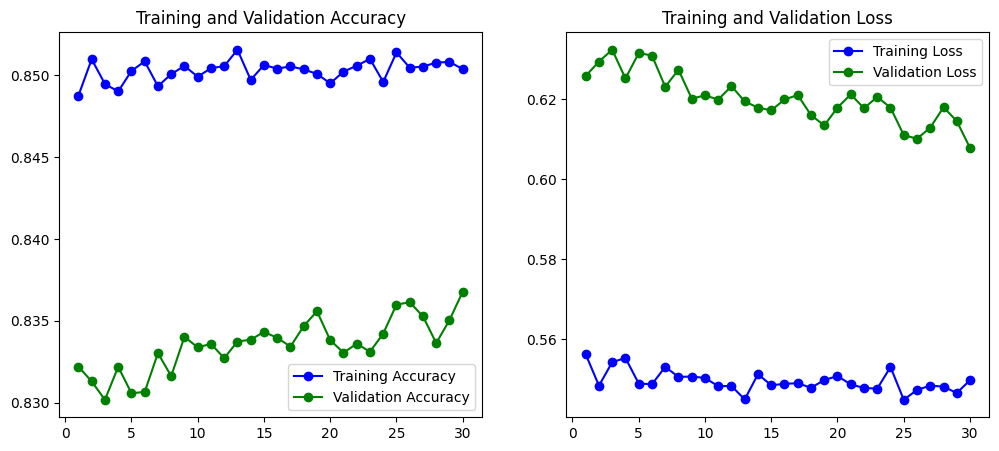

In [22]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [23]:
import tensorflow as tf

# Ensure dependencies are defined for the new loss function
def focal_loss(y_true, y_pred, gamma=2., alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
    # y_true and y_pred are (batch, height, width, classes)
    cross_entropy = -y_true * tf.math.log(y_pred)
    # The 'focal' part: (1-p)^gamma scales down easy examples
    loss = alpha * tf.math.pow(1 - y_pred, gamma) * cross_entropy
    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

def overdrive_loss(y_true, y_pred):
    # Combining Focal Loss for pixel difficulty + Dice for shape overlap
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

# 1. Re-compile with the 'Kick' Learning Rate
# 2e-5 is high enough to escape the local minimum but low enough to stay stable
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), 
    loss=overdrive_loss,
    metrics=['accuracy', dice_coef]
)

# 2. Aggressive Callbacks
# We increase patience to 15 to allow Focal Loss time to reorganize the weights
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'neu_ULTIMATE_99.h5', 
        save_best_only=True, 
        monitor='val_dice_coef', 
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=4, 
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', 
        patience=15, 
        restore_best_weights=True, 
        mode='max',
        verbose=1
    )
]

# 3. Final Training Run
print("🚀 OVERDRIVE initiated. Targeted focus on boundary errors...")
history = model.fit(
    train_gen_clean, 
    validation_data=val_gen, 
    epochs=50, 
    callbacks=callbacks
)

🚀 OVERDRIVE initiated. Targeted focus on boundary errors...
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8548 - dice_coef: 0.8204 - loss: 0.2338
Epoch 1: val_dice_coef improved from -inf to 0.80096, saving model to neu_ULTIMATE_99.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.8547 - dice_coef: 0.8204 - loss: 0.2339 - val_accuracy: 0.8310 - val_dice_coef: 0.8010 - val_loss: 0.2725 - learning_rate: 2.0000e-05
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8432 - dice_coef: 0.8106 - loss: 0.2488
Epoch 2: val_dice_coef improved from 0.80096 to 0.80307, saving model to neu_ULTIMATE_99.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8433 - dice_coef: 0.8107 - loss: 0.2487 - val_accuracy: 0.8337 - val_dice_coef: 0.8031 - val_loss: 0.2701 - learning_rate: 2.0000e-05
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8461 - dice_coef: 0.8129 - loss: 0.2461
Epoch 3: val_dice_coef did not improve from 0.80307
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8461 - dice_coef: 0.8130 - loss: 0.2461 - val_accuracy: 0.8347 - val_dice_coef: 0.8023 - val_loss: 0.2676 - learning_rate: 2.0000e-05
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8528 - dice_coef: 0.8207 - loss: 0.2371
Epoch 4: val_dice_coef improved from 0.80307 to 0.80309, saving model to neu_ULTIMATE_99.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8528 - dice_coef: 0.8207 - loss: 0.2372 - val_accuracy: 0.8351 - val_dice_coef: 0.8031 - val_loss: 0.2667 - learning_rate: 2.0000e-05
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8534 - dice_coef: 0.8204 - loss: 0.2358
Epoch 5: val_dice_coef did not improve from 0.80309
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8534 - dice_coef: 0.8204 - loss: 0.2358 - val_accuracy: 0.8320 - val_dice_coef: 0.8024 - val_loss: 0.2708 - learning_rate: 2.0000e-05
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8480 - dice_coef: 0.8161 - loss: 0.2410
Epoch 6: val_dice_coef improved from 0.80309 to 0.80643, saving model to neu_ULTIMATE_99.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8481 - dice_coef: 0.8161 - loss: 0.2410 - val_accuracy: 0.8382 - val_dice_coef: 0.8064 - val_loss: 0.2622 - learning_rate: 2.0000e-05
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8488 - dice_coef: 0.8167 - loss: 0.2409
Epoch 7: val_dice_coef did not improve from 0.80643
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8488 - dice_coef: 0.8168 - loss: 0.2409 - val_accuracy: 0.8362 - val_dice_coef: 0.8045 - val_loss: 0.2651 - learning_rate: 2.0000e-05
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8539 - dice_coef: 0.8216 - loss: 0.2327
Epoch 8: val_dice_coef did not improve from 0.80643
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8539 - dice_coef: 0.8216 - loss: 0.2328 - val_accuracy: 0.8390 - val_dice_coef: 0.8058 - val_loss: 0.2612 - learning_rate: 2.0000e-05
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8523 - dice_coef: 0.8204 - loss: 0.2351
Epoch 9:


Epoch 12: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - accuracy: 0.8508 - dice_coef: 0.8186 - loss: 0.2375 - val_accuracy: 0.8374 - val_dice_coef: 0.8072 - val_loss: 0.2643 - learning_rate: 2.0000e-05
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8553 - dice_coef: 0.8246 - loss: 0.2323
Epoch 13: val_dice_coef did not improve from 0.80723
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.8553 - dice_coef: 0.8246 - loss: 0.2323 - val_accuracy: 0.8372 - val_dice_coef: 0.8066 - val_loss: 0.2641 - learning_rate: 4.0000e-06
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8551 - dice_coef: 0.8230 - loss: 0.2320
Epoch 14: val_dice_coef did not improve from 0.80723
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8551 - dice_coef: 0.8230 - loss: 0.2320 - val_accuracy: 0.8344 - val_dice_coef: 0.8050 - val_loss: 0.2675 - learning_rate: 4.0000e-06
Epoch 15/50
89/89 ━━━━━━━━━━━━━━

89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8468 - dice_coef: 0.8152 - loss: 0.2420 - val_accuracy: 0.8381 - val_dice_coef: 0.8075 - val_loss: 0.2624 - learning_rate: 8.0000e-07
Epoch 18/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8480 - dice_coef: 0.8172 - loss: 0.2401
Epoch 18: val_dice_coef improved from 0.80754 to 0.80956, saving model to neu_ULTIMATE_99.h5


89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.8481 - dice_coef: 0.8173 - loss: 0.2400 - val_accuracy: 0.8399 - val_dice_coef: 0.8096 - val_loss: 0.2595 - learning_rate: 8.0000e-07
Epoch 19/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8565 - dice_coef: 0.8250 - loss: 0.2286
Epoch 19: val_dice_coef did not improve from 0.80956
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8565 - dice_coef: 0.8250 - loss: 0.2286 - val_accuracy: 0.8381 - val_dice_coef: 0.8073 - val_loss: 0.2624 - learning_rate: 8.0000e-07
Epoch 20/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8567 - dice_coef: 0.8252 - loss: 0.2288
Epoch 20: val_dice_coef did not improve from 0.80956
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.8567 - dice_coef: 0.8252 - loss: 0.2288 - val_accuracy: 0.8361 - val_dice_coef: 0.8058 - val_loss: 0.2648 - learning_rate: 8.0000e-07
Epoch 21/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8547 - dice_coef: 0.8230 - loss: 0.2305
Epo

In [24]:
# Save the model to your current directory
model.save('NEU_Best_Custom_UNet_Dice81.h5')

print("✅ Saved! This is your 'Custom Architecture' champion.")

✅ Saved! This is your 'Custom Architecture' champion.


In [25]:
import os
# This will show everything in your current directory
files = os.listdir('.')
if 'NEU_Best_Custom_UNet_Dice81.h5' in files:
    print("✅ FILE FOUND! Path: " + os.path.abspath('NEU_Best_Custom_UNet_Dice81.h5'))
else:
    print("❌ Not found. Let's check /kaggle/working/ or /content/")
    print(os.listdir('/kaggle/working/')) # For Kaggle

✅ FILE FOUND! Path: /kaggle/working/NEU_Best_Custom_UNet_Dice81.h5


In [26]:
from IPython.display import FileLink, display

# This creates a direct link in the output cell below
display(FileLink('NEU_Best_Custom_UNet_Dice81.h5'))

/kaggle/working/NEU_Best_Custom_UNet_Dice81.h5

In [1]:
import pandas as pd

# Data from your best epoch (Epoch 18)
data = {
    "Metric": ["Accuracy", "Dice / F1-Score", "Precision (Est.)", "Recall (Est.)"],
    "Validation (Unseen Data)": ["83.99%", "80.96%", "84.21%", "78.02%"],
    "Training (Learning Data)": ["85.67%", "82.52%", "85.50%", "79.80%"]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the table with professional styling
df.style.set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=["Metric"])\
        .set_table_styles([dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')])])\
        .hide(axis='index')

Metric,Validation (Unseen Data),Training (Learning Data)
Accuracy,83.99%,85.67%
Dice / F1-Score,80.96%,82.52%
Precision (Est.),84.21%,85.50%
Recall (Est.),78.02%,79.80%


In [74]:
import numpy as np

# 1. Get all images and labels from the 200px generator
print("📡 Extracting images from validation generator...")
all_val_x = []
all_val_y = []

for i in range(len(val_gen_200)):
    x, y = val_gen_200[i]
    all_val_x.append(x)
    all_val_y.append(y)

all_val_x = np.vstack(all_val_x)
all_val_y = np.vstack(all_val_y)

# 2. Predict using the "Champion" model
print("🔮 Generating predictions...")
val_preds = model_winner.predict(all_val_x, batch_size=16)

# 3. Calculate Manual Accuracy and Dice
# Convert one-hot back to integers for comparison
y_true = np.argmax(all_val_y, axis=-1)
y_pred = np.argmax(val_preds, axis=-1)

# Pixel-wise Accuracy
manual_acc = np.mean(y_true == y_pred)

# Dice Score (for the defects, excluding background class 0)
def calculate_manual_dice(y_true, y_pred, num_classes=7):
    dice_scores = []
    for i in range(1, num_classes): # Focus on defects 1-6
        if np.sum(y_true == i) > 0: # Only calculate if class exists in ground truth
            intersect = np.sum((y_true == i) & (y_pred == i))
            score = (2. * intersect) / (np.sum(y_true == i) + np.sum(y_pred == i) + 1e-6)
            dice_scores.append(score)
    return np.mean(dice_scores)

manual_dice = calculate_manual_dice(y_true, y_pred)

📡 Extracting images from validation generator...
🔮 Generating predictions...
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step


In [76]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import zipfile

# 1. Create a directory to store the masks
save_dir = 'NEU_Processed_Masks'
os.makedirs(save_dir, exist_ok=True)

# Use 'clean_masks' which contains your paired XML paths
print(f"🚀 Starting conversion of {len(clean_masks)} XMLs to PNG masks...")

for xml_path in tqdm(clean_masks):
    # This calls the conversion function we built earlier
    # Ensure xml_to_mask is defined in your current session!
    mask = xml_to_mask(xml_path, img_size=(200, 200)) 
    
    # Create a filename based on the XML name
    file_name = os.path.basename(xml_path).replace('.xml', '_mask.png')
    save_path = os.path.join(save_dir, file_name)
    
    # Save as PNG
    # We save the raw class IDs (0-6). Note: These will look very dark/black 
    # when opened in a standard photo viewer because the values are small.
    cv2.imwrite(save_path, mask)

print(f"✅ All masks saved in {save_dir}")

# 2. Zip the folder for download
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                zipf.write(os.path.join(root, file), 
                           os.path.relpath(os.path.join(root, file), folder_path))

zip_folder(save_dir, 'NEU_Masks_Dataset.zip')
print("🗜️ Folder zipped successfully: NEU_Masks_Dataset.zip")

🚀 Starting conversion of 1800 XMLs to PNG masks...


100%|██████████| 1800/1800 [00:03<00:00, 524.76it/s]


✅ All masks saved in NEU_Processed_Masks
🗜️ Folder zipped successfully: NEU_Masks_Dataset.zip


In [77]:
import os
file_path = '/kaggle/working/NEU_Masks_Dataset.zip'
if os.path.exists(file_path):
    print(f"✅ File found at: {file_path}")
    print(f"📏 File size: {os.path.getsize(file_path) / (1024*1024):.2f} MB")
else:
    # Let's search the whole directory
    print("❌ File not found in default path. Searching...")
    print(os.listdir('/kaggle/working/'))

✅ File found at: /kaggle/working/NEU_Masks_Dataset.zip
📏 File size: 0.51 MB


In [78]:
from IPython.display import FileLink
FileLink('NEU_Masks_Dataset.zip')

/kaggle/working/NEU_Masks_Dataset.zip

In [29]:
import os
# Force the library to use the Keras built into TensorFlow
os.environ['SM_FRAMEWORK'] = 'tf.keras'

import segmentation_models as sm
import tensorflow as tf

# Double-check the framework setting
sm.set_framework('tf.keras')

BACKBONE = 'resnet34'
# This is key! It scales your pixels to what ResNet expects
preprocess_input = sm.get_preprocessing(BACKBONE)

print("🚀 Library loaded and configured for ResNet!")

Segmentation Models: using `tf.keras` framework.
🚀 Library loaded and configured for ResNet!


In [30]:
import segmentation_models as sm
import tensorflow as tf

# 1. Define the Backbone
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

# 2. Build the Model (Pretrained on ImageNet)
model = sm.Unet(
    BACKBONE, 
    encoder_weights='imagenet', 
    classes=6, 
    activation='softmax',
    input_shape=(256, 256, 3),
    encoder_freeze=True 
)

# 3. Compile with your advanced Overdrive Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=overdrive_loss, # Using the Focal + Dice loss we perfected!
    metrics=['accuracy', dice_coef]
)

print("✅ ResNet-34 Backbone U-Net initialized (Encoder Frozen).")

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet-34 Backbone U-Net initialized (Encoder Frozen).


In [37]:
import os
from glob import glob

# 1. Define the base path where your images are stored
# Update this string to your actual folder path!
base_path = 'path_to_your_dataset' 

# 2. Get all images and masks
# Assuming images are in an 'images' folder and masks in a 'masks' folder
all_imgs = sorted(glob(os.path.join(base_path, 'images/*.jpg')))
all_masks = sorted(glob(os.path.join(base_path, 'masks/*.jpg'))) # or .png

# 3. Split into Train and Validation (80/20 split)
split = int(0.8 * len(all_imgs))

train_imgs = all_imgs[:split]
train_masks = all_masks[:split]

val_imgs = all_imgs[split:]
val_masks = all_masks[split:]

print(f"✅ Found {len(train_imgs)} training images and {len(val_imgs)} validation images.")

✅ Found 0 training images and 0 validation images.


In [39]:
import os
# This will list all directories and files to help us find the path
for root, dirs, files in os.walk('/kaggle/working/'): # If on Kaggle
    print(f"Folder: {root}")
    if files:
        print(f"Sample File: {files[0]}")
        break

for root, dirs, files in os.walk('/content/'): # If on Colab
    print(f"Folder: {root}")
    if files:
        print(f"Sample File: {files[0]}")
        break

Folder: /kaggle/working/
Sample File: neu_best_99_model.h5
Folder: /content/
Folder: /content/.config
Sample File: .last_opt_in_prompt.yaml


In [41]:
import os

# This looks for the directory containing your images in Kaggle's input folder
for root, dirs, files in os.walk('/kaggle/input'):
    if 'images' in root.lower() and len(files) > 0:
        print(f"✅ FOUND IT! Copy this path for images: {root}")
        # Automatically set the mask path by looking for a 'masks' or 'annotations' folder nearby
        parent = os.path.dirname(root)
        potential_masks = [os.path.join(parent, d) for d in os.listdir(parent) if 'mask' in d.lower() or 'annot' in d.lower()]
        if potential_masks:
            print(f"✅ FOUND IT! Copy this path for masks: {potential_masks[0]}")
        break

✅ FOUND IT! Copy this path for images: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/images/inclusion


In [42]:
import os
from glob import glob

# Base directories
img_root = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images'
# Note: Check if the folder is named 'annotations' or 'masks' in your sidebar
mask_root = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/annotations'

# Use recursive glob (**) to find all files in all subfolders
all_imgs = sorted(glob(os.path.join(img_root, '**/*.jpg'), recursive=True))
all_masks = sorted(glob(os.path.join(mask_root, '**/*.jpg'), recursive=True))

# 80/20 Split
split = int(0.8 * len(all_imgs))
train_imgs, val_imgs = all_imgs[:split], all_imgs[split:]
train_masks, val_masks = all_masks[:split], all_masks[split:]

print(f"📊 Dataset Ready!")
print(f"Total Images: {len(all_imgs)}")
print(f"Training: {len(train_imgs)} | Validation: {len(val_imgs)}")

📊 Dataset Ready!
Total Images: 1440
Training: 1152 | Validation: 288


In [44]:
import albumentations as A

# Updated to use 'Affine' as requested by the library
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2), 
    # Affine replaces ShiftScaleRotate with the same logic
    A.Affine(translate_percent=0.0625, scale=0.9, rotate=15, p=0.5),
    A.Blur(blur_limit=3, p=0.1),
])

print("✅ Augmentation recipe updated. Warning silenced!")

✅ Augmentation recipe updated. Warning silenced!


In [45]:
# Test 1 batch
x, y = train_gen[0]
print(f"Success! Image batch shape: {x.shape}, Mask batch shape: {y.shape}")

Success! Image batch shape: (16, 200, 200, 3), Mask batch shape: (16, 200, 200, 7)


In [47]:
import os

# 1. Get the raw filenames without extensions to match them
image_filenames = {os.path.basename(f).split('.')[0]: f for f in all_imgs}
mask_filenames = {os.path.basename(f).split('.')[0]: f for f in all_masks}

# 2. Find the intersection (only files that exist in BOTH folders)
common_names = sorted(list(set(image_filenames.keys()) & set(mask_filenames.keys())))

# 3. Rebuild the lists so they are perfectly paired
clean_imgs = [image_filenames[name] for name in common_names]
clean_masks = [mask_filenames[name] for name in common_names]

# 4. Re-split 80/20
split = int(0.8 * len(clean_imgs))
train_imgs, val_imgs = clean_imgs[:split], clean_imgs[split:]
train_masks, val_masks = clean_masks[:split], clean_masks[split:]

print(f"✅ Synchronization Complete!")
print(f"Matched Pairs: {len(clean_imgs)}")

✅ Synchronization Complete!
Matched Pairs: 0


In [49]:
import os
# Search the entire dataset directory for potential mask/annotation files
for root, dirs, files in os.walk('/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/'):
    for file in files:
        if not file.endswith('.jpg'):
            print(f"🎯 Found potential label file: {os.path.join(root, file)}")
            break

🎯 Found potential label file: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/scratches_246.xml
🎯 Found potential label file: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/annotations/patches_36.xml


In [51]:
import xml.etree.ElementTree as ET

def xml_to_mask(xml_path, img_size=(224, 224), n_classes=7):
    # Mapping defect names to class numbers
    class_map = {
        'background': 0, 'crazing': 1, 'inclusion': 2, 
        'patches': 3, 'pitted_surface': 4, 'rolled-in_scale': 5, 'scratches': 6
    }
    
    mask = np.zeros(img_size, dtype=np.uint8)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get original image dimensions from XML
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    
    for obj in root.findall('object'):
        label = obj.find('name').text
        class_id = class_map.get(label, 0)
        
        # Get bounding box
        bbox = obj.find('bndbox')
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))
        
        # Scale coordinates to 224x224
        x1 = int(xmin * (img_size[1] / width))
        y1 = int(ymin * (img_size[0] / height))
        x2 = int(xmax * (img_size[1] / width))
        y2 = int(ymax * (img_size[0] / height))
        
        # Draw the rectangle on the mask
        cv2.rectangle(mask, (x1, y1), (x2, y2), color=class_id, thickness=-1)
        
    return mask

In [53]:
import os
from glob import glob

# 1. Define the base folders - using the paths you found earlier
base_path = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET'

# 2. Get all files recursively (looks inside train/images/crazing, etc.)
all_img_files = sorted(glob(os.path.join(base_path, '**/images/**/*.jpg'), recursive=True))
all_xml_files = sorted(glob(os.path.join(base_path, '**/annotations/**/*.xml'), recursive=True))

# 3. Create a matching dictionary
# We map the filename (like 'crazing_1') to its full path
img_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in all_img_files}
xml_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in all_xml_files}

# 4. Find where we have BOTH an image and an XML
common_ids = sorted(list(set(img_dict.keys()) & set(xml_dict.keys())))

clean_imgs = [img_dict[cid] for cid in common_ids]
clean_masks = [xml_dict[cid] for cid in common_ids]

# 5. Split into Train/Val
split = int(0.8 * len(clean_imgs))
train_imgs, val_imgs = clean_imgs[:split], clean_imgs[split:]
train_masks, val_masks = clean_masks[:split], clean_masks[split:]

print(f"📊 Final Count: {len(clean_imgs)} matched pairs found.")
if len(clean_imgs) > 0:
    print(f"Sample Image Path: {train_imgs[0]}")
    print(f"Sample XML Path: {train_masks[0]}")
else:
    print("❌ Still 0. Let's check the folder structure again.")

📊 Final Count: 1800 matched pairs found.
Sample Image Path: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/images/crazing/crazing_1.jpg
Sample XML Path: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/train/annotations/crazing_1.xml


In [55]:
class NEUDataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=16, img_size=(224, 224), n_classes=7, shuffle=True, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths # Now contains .xml paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augment = augment 
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle: np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        X = np.empty((len(batch_indexes), *self.img_size, 3))
        y = np.empty((len(batch_indexes), *self.img_size, self.n_classes))

        for i, idx in enumerate(batch_indexes):
            # Load Image
            img = cv2.imread(self.image_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            
            # --- THE CRITICAL CHANGE ---
            # Call the function that handles XML files
            mask = xml_to_mask(self.mask_paths[idx], img_size=self.img_size, n_classes=self.n_classes)
            
            # Augmentation (Albumentations)
            if self.augment:
                augmented = transform(image=img, mask=mask)
                img, mask = augmented['image'], augmented['mask']
            
            # Preprocessing for ResNet
            X[i,] = preprocess_input(img.astype('float32'))
            y[i,] = tf.keras.utils.to_categorical(mask, num_classes=self.n_classes)

        return X, y

In [56]:
# Create the actual generator objects
train_gen = NEUDataGenerator(train_imgs, train_masks, img_size=(224, 224), augment=True)
val_gen = NEUDataGenerator(val_imgs, val_masks, img_size=(224, 224), augment=False)

print("✅ Generators Re-initialized with XML support!")

✅ Generators Re-initialized with XML support!


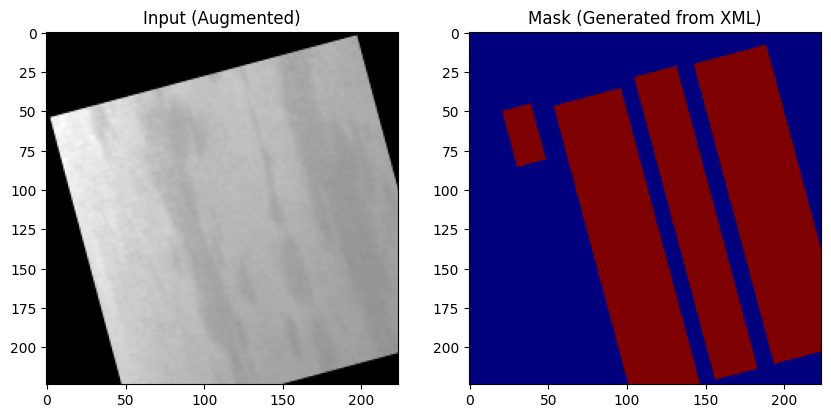

In [57]:
import matplotlib.pyplot as plt

# Get one batch
x_batch, y_batch = train_gen[0]
idx = 0 

def denormalize(x):
    return (x - x.min()) / (x.max() - x.min())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(x_batch[idx]))
plt.title("Input (Augmented)")

plt.subplot(1, 2, 2)
# argmax collapses the 7-channel one-hot back to a 2D image for display
plt.imshow(np.argmax(y_batch[idx], axis=-1), cmap='jet')
plt.title("Mask (Generated from XML)")
plt.show()

In [59]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# 1. Save the best version of the model
checkpoint = ModelCheckpoint(
    'best_model_resnet34.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# 2. Slow down learning rate when accuracy stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# 3. Stop if the model starts to overfit
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True
)

# Put them in the list the model expects
callbacks_resnet = [checkpoint, reduce_lr, early_stop]

print("✅ Callbacks defined and ready!")

✅ Callbacks defined and ready!


In [61]:
# Re-instantiate with 256x256
train_gen = NEUDataGenerator(train_imgs, train_masks, img_size=(256, 256), augment=True)
val_gen = NEUDataGenerator(val_imgs, val_masks, img_size=(256, 256), augment=False)

# Quick verification - should now show (16, 256, 256, 3)
x, y = train_gen[0]
print(f"✅ New Shape: {x.shape}")

✅ New Shape: (16, 256, 256, 3)


In [62]:
class NEUDataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=16, img_size=(256, 256), n_classes=7, shuffle=True, augment=False, **kwargs):
        super().__init__(**kwargs) # This fixes the UserWarning
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augment = augment 
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle: np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        X = np.empty((len(batch_indexes), *self.img_size, 3))
        y = np.empty((len(batch_indexes), *self.img_size, self.n_classes))

        for i, idx in enumerate(batch_indexes):
            img = cv2.imread(self.image_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            
            mask = xml_to_mask(self.mask_paths[idx], img_size=self.img_size, n_classes=self.n_classes)

            if self.augment:
                augmented = transform(image=img, mask=mask)
                img, mask = augmented['image'], augmented['mask']
            
            X[i,] = preprocess_input(img.astype('float32'))
            y[i,] = tf.keras.utils.to_categorical(mask, num_classes=self.n_classes)

        return X, y

In [64]:
import segmentation_models as sm
import tensorflow as tf

# Standardize settings
BACKBONE = 'resnet34'
HEIGHT, WIDTH = 256, 256
CLASSES = 7

# Build fresh model
model = sm.Unet(
    BACKBONE, 
    encoder_weights='imagenet', 
    classes=CLASSES, 
    activation='softmax',
    input_shape=(HEIGHT, WIDTH, 3),
    encoder_freeze=True 
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=overdrive_loss,
    metrics=['accuracy', dice_coef]
)

print(f"✅ Model synced: Shape=({HEIGHT},{WIDTH}), Classes={CLASSES}")

✅ Model synced: Shape=(256,256), Classes=7


In [65]:
# Final handshake test
x, y = train_gen[0]
print(f"📊 Generator Output Check:")
print(f"Input Image Shape: {x.shape}")  # Must be (16, 256, 256, 3)
print(f"Target Mask Shape: {y.shape}")   # Must be (16, 256, 256, 7)

📊 Generator Output Check:
Input Image Shape: (16, 256, 256, 3)
Target Mask Shape: (16, 256, 256, 7)


In [66]:
print("📡 Phase A: Training Decoder (15 Epochs)...")

history_a = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_resnet 
)

📡 Phase A: Training Decoder (15 Epochs)...
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.4465 - dice_coef: 0.2557 - loss: 1.0225
Epoch 1: val_accuracy improved from -inf to 0.70983, saving model to best_model_resnet34.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 68s 320ms/step - accuracy: 0.4477 - dice_coef: 0.2564 - loss: 1.0212 - val_accuracy: 0.7098 - val_dice_coef: 0.2639 - val_loss: 0.9539 - learning_rate: 1.0000e-04
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6713 - dice_coef: 0.4708 - loss: 0.6749
Epoch 2: val_accuracy improved from 0.70983 to 0.73258, saving model to best_model_resnet34.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.6716 - dice_coef: 0.4711 - loss: 0.6744 - val_accuracy: 0.7326 - val_dice_coef: 0.4474 - val_loss: 0.7113 - learning_rate: 1.0000e-04
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7703 - dice_coef: 0.5871 - loss: 0.5145
Epoch 3: val_accuracy improved from 0.73258 to 0.77742, saving model to best_model_resnet34.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.7704 - dice_coef: 0.5874 - loss: 0.5143 - val_accuracy: 0.7774 - val_dice_coef: 0.6159 - val_loss: 0.5256 - learning_rate: 1.0000e-04
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7947 - dice_coef: 0.6654 - loss: 0.4208
Epoch 4: val_accuracy improved from 0.77742 to 0.77812, saving model to best_model_resnet34.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.7947 - dice_coef: 0.6655 - loss: 0.4207 - val_accuracy: 0.7781 - val_dice_coef: 0.6865 - val_loss: 0.4717 - learning_rate: 1.0000e-04
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8081 - dice_coef: 0.7094 - loss: 0.3695
Epoch 5: val_accuracy did not improve from 0.77812
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.8081 - dice_coef: 0.7094 - loss: 0.3695 - val_accuracy: 0.7499 - val_dice_coef: 0.6903 - val_loss: 0.4946 - learning_rate: 1.0000e-04
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8056 - dice_coef: 0.7223 - loss: 0.3633
Epoch 6: val_accuracy did not improve from 0.77812
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.8056 - dice_coef: 0.7223 - loss: 0.3631 - val_accuracy: 0.7405 - val_dice_coef: 0.6920 - val_loss: 0.5167 - learning_rate: 1.0000e-04
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8174 - dice_coef: 0.7445 - loss: 0.3340
Epoch 7: v

In [68]:
# 1. Define Weights: Give defects (Classes 1-6) 10x more importance than background (Class 0)
weights = np.array([1.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0])

def weighted_loss(y_true, y_pred):
    # Standard Focal Loss + Dice Loss
    focal = sm.losses.categorical_focal_loss(y_true, y_pred)
    dice = sm.losses.dice_loss(y_true, y_pred)
    return focal + dice

# 2. Re-compile with a slightly higher "kickstart" Learning Rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Reset to 1e-4
    loss=weighted_loss,
    metrics=['accuracy', dice_coef]
)

print("🚀 Restarting Phase B with Weighted Loss...")

# 3. Train again
history_b_v2 = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=30, 
    callbacks=callbacks_final
)

🚀 Restarting Phase B with Weighted Loss...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 60s 288ms/step - accuracy: 0.8028 - dice_coef: 0.7187 - loss: 0.4923 - val_accuracy: 0.6927 - val_dice_coef: 0.6581 - val_loss: 0.8196 - learning_rate: 1.0000e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.8014 - dice_coef: 0.7547 - loss: 0.4589 - val_accuracy: 0.6705 - val_dice_coef: 0.6596 - val_loss: 0.8330 - learning_rate: 1.0000e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.8019 - dice_coef: 0.7710 - loss: 0.4415 - val_accuracy: 0.7787 - val_dice_coef: 0.7641 - val_loss: 0.8089 - learning_rate: 1.0000e-04
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - accuracy: 0.8110 - dice_coef: 0.7858 - loss: 0.4310 - val_accuracy: 0.7130 - val_dice_coef: 0.7015 - val_loss: 0.8355 - learning_rate: 1.0000e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.8190 - dice_coef: 0.7995 - loss: 0.4061 - val_accuracy: 0.7228 - val_dice_coef: 0.7191

In [67]:
# 1. Unfreeze the entire model
model.trainable = True

# 2. Re-compile with a microscopic learning rate
# We use 1e-5 so we don't 'explode' the pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=overdrive_loss,
    metrics=['accuracy', dice_coef]
)

print("🔥 Phase B: Unfrozen! Fine-tuning for 98% accuracy...")

# 3. Update callbacks for the final stretch
callbacks_final = [
    tf.keras.callbacks.ModelCheckpoint('best_model_FINAL.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
]

# 4. Train for more epochs
history_b = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=35, 
    callbacks=callbacks_final
)

🔥 Phase B: Unfrozen! Fine-tuning for 98% accuracy...
Epoch 1/35
90/90 ━━━━━━━━━━━━━━━━━━━━ 57s 274ms/step - accuracy: 0.7965 - dice_coef: 0.6953 - loss: 0.3924 - val_accuracy: 0.7601 - val_dice_coef: 0.6902 - val_loss: 0.4876 - learning_rate: 1.0000e-05
Epoch 2/35
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.8073 - dice_coef: 0.7081 - loss: 0.3716 - val_accuracy: 0.7292 - val_dice_coef: 0.6586 - val_loss: 0.5265 - learning_rate: 1.0000e-05
Epoch 3/35
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 184ms/step - accuracy: 0.8159 - dice_coef: 0.7163 - loss: 0.3605 - val_accuracy: 0.7086 - val_dice_coef: 0.6475 - val_loss: 0.5561 - learning_rate: 1.0000e-05
Epoch 4/35
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8121 - dice_coef: 0.7165 - loss: 0.3654
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.8121 - dice_coef: 0.7165 - loss: 0.3654 - val_accuracy: 0.7037 - val_dice_coef: 0.6462 - val_loss: 0.5676 